In [1]:
import math
import os
import tempfile

import pandas as pd
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed

from tsfm_public import (
    TimeSeriesPreprocessor,
    TinyTimeMixerForPrediction,
    TrackingCallback,
    count_parameters,
    get_datasets,
)
from tsfm_public.toolkit.visualization import plot_predictions

2024-10-14 02:23:12.553423: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-14 02:23:12.553451: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-14 02:23:12.554420: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-14 02:23:12.560799: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-14 02:23:13.543386: W tensorflow/compiler/tf2

In [2]:
# TTM_MODEL_REVISION = "1024_96_v1"
# zeroshot_model = TinyTimeMixerForPrediction.from_pretrained(
#     "ibm-granite/granite-timeseries-ttm-v1", revision=TTM_MODEL_REVISION
# )

In [3]:
# Set seed for reproducibility
SEED = 42
set_seed(SEED)

# Results dir
OUT_DIR = "ttm_finetuned_models/"

# TTM model branch
# Use main for 512-96 model
# Use "1024_96_v1" for 1024-96 model
TTM_MODEL_REVISION = "1024_96_v1"

# Forecasting parameters
context_length = 1024
forecast_length = 96
fewshot_fraction = 0.05

In [4]:
clusters_counts = []
for i in range(27):
    clusters_counts.append(pd.read_csv(f"/home/mohamed/Mohamed/Vodafone_project/projects/app/visualization/area_clusters_dir/counts_{i}.csv", names=["time", "count"]))

In [5]:
for i in range(27):
    clusters_counts[i]['time'] = pd.to_datetime(clusters_counts[i]['time'])

In [6]:
data_length = len(clusters_counts[1])

In [7]:
train_len = int(data_length * 0.90)
valid_len = int(data_length * 0.05)
test_len = int(data_length * 0.05)
train_len, valid_len, test_len

(473040, 26280, 26280)

In [8]:
timestamp_column = "time"
id_columns = []
target_columns = ["count"]
split_config = {
    "train": 0.70,
    "test": 0.20,
}
# Understanding the split config -- slides

data_sets = []
for i in range(27):
    data = clusters_counts[i]

    column_specifiers = {
        "timestamp_column": timestamp_column,
        "id_columns": id_columns,
        "target_columns": target_columns,
        "control_columns": [],
    }

    tsp = TimeSeriesPreprocessor(
        **column_specifiers,
        context_length=context_length,
        prediction_length=forecast_length,
        scaling=True,
        encode_categorical=False,
        scaler_type="standard",
    )

    train_dataset, valid_dataset, test_dataset = get_datasets(
        tsp, data, split_config, fewshot_fraction=fewshot_fraction, fewshot_location="first"
    )
    print(f"Data lengths: train = {len(train_dataset)}, val = {len(valid_dataset)}, test = {len(test_dataset)}")

    data_sets.append((train_dataset, valid_dataset, test_dataset))



Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test = 105025
Data lengths: train = 18249, val = 52465, test =

In [9]:
# temp_dir = tempfile.mkdtemp()
# # zeroshot_trainer
# zeroshot_trainer = Trainer(
#     model=zeroshot_model,
#     args=TrainingArguments(
#         output_dir=temp_dir,
#         per_device_eval_batch_size=64,
#     ),
# )

In [10]:
# zeroshot_trainer.evaluate(data_sets[0][2])

In [11]:
# # plot
# plot_predictions(
#     model=zeroshot_trainer.model,
#     dset=data_sets[0][2],
#     plot_dir=os.path.join(OUT_DIR, "ettm2"),
#     plot_prefix="test_zeroshot",
#     channel=0,
#     num_plots=3,
# )

In [12]:
fine_tune_models = []
for i in range(27):
    fine_tune_models.append( TinyTimeMixerForPrediction.from_pretrained(
        "ibm-granite/granite-timeseries-ttm-v1", revision=TTM_MODEL_REVISION, head_dropout=0.7
    ))
fine_tune_models

[TinyTimeMixerForPrediction(
   (backbone): TinyTimeMixerModel(
     (encoder): TinyTimeMixerEncoder(
       (patcher): Linear(in_features=64, out_features=192, bias=True)
       (mlp_mixer_encoder): TinyTimeMixerBlock(
         (mixers): ModuleList(
           (0): TinyTimeMixerAdaptivePatchingBlock(
             (mixer_layers): ModuleList(
               (0-1): 2 x TinyTimeMixerLayer(
                 (patch_mixer): PatchMixerBlock(
                   (norm): TinyTimeMixerNormLayer(
                     (norm): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
                   )
                   (mlp): TinyTimeMixerMLP(
                     (fc1): Linear(in_features=64, out_features=128, bias=True)
                     (dropout1): Dropout(p=0.2, inplace=False)
                     (fc2): Linear(in_features=128, out_features=64, bias=True)
                     (dropout2): Dropout(p=0.2, inplace=False)
                   )
                   (gating_block): TinyTimeMixerGatedAtt

In [13]:
# Freeze the backbone of the model
for i in range(27):
    print(
        "Number of params before freezing backbone",
        count_parameters(fine_tune_models[i]),
    )
    for param in fine_tune_models[i].backbone.parameters():
        param.requires_grad = False

    # Count params
    print(
        "Number of params after freezing the backbone",
        count_parameters(fine_tune_models[i]),
    )

Number of params before freezing backbone 946336
Number of params after freezing the backbone 389984
Number of params before freezing backbone 946336
Number of params after freezing the backbone 389984
Number of params before freezing backbone 946336
Number of params after freezing the backbone 389984
Number of params before freezing backbone 946336
Number of params after freezing the backbone 389984
Number of params before freezing backbone 946336
Number of params after freezing the backbone 389984
Number of params before freezing backbone 946336
Number of params after freezing the backbone 389984
Number of params before freezing backbone 946336
Number of params after freezing the backbone 389984
Number of params before freezing backbone 946336
Number of params after freezing the backbone 389984
Number of params before freezing backbone 946336
Number of params after freezing the backbone 389984
Number of params before freezing backbone 946336
Number of params after freezing the backbo

In [15]:
# Important parameters
learning_rate = 0.0005
num_epochs = 2  # Ideally, we need more epochs (try offline preferably in a gpu for faster computation)
batch_size = 1024

In [16]:
os.environ["WANDB_PROJECT"] = "areas_forcast_models_by_cluster" 

In [17]:
import uuid
finetune_forecast_args_list = []
for i in range(27):
    print(f"cluster_{i}")
    finetune_forecast_args = TrainingArguments(
        output_dir=os.path.join(OUT_DIR, f"{i}"),
        overwrite_output_dir=True,
        learning_rate=learning_rate,
        num_train_epochs=num_epochs,
        do_eval=True,
        eval_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        dataloader_num_workers=8,
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        logging_dir=os.path.join(OUT_DIR, "logs"),  # Make sure to specify a logging directory
        load_best_model_at_end=True,  # Load the best model when training ends
        metric_for_best_model="eval_loss",  # Metric to monitor for early stopping
        greater_is_better=False,  # For loss
        report_to="wandb",  # enable logging to W&B
        run_name=f"cluster_{i}_run_{uuid.uuid4()}",  # name of the W&B run (optional)
    )
    finetune_forecast_args_list.append(finetune_forecast_args)


cluster_0
cluster_1
cluster_2
cluster_3
cluster_4
cluster_5
cluster_6
cluster_7
cluster_8
cluster_9
cluster_10
cluster_11
cluster_12
cluster_13
cluster_14
cluster_15
cluster_16
cluster_17
cluster_18
cluster_19
cluster_20
cluster_21
cluster_22
cluster_23
cluster_24
cluster_25
cluster_26


In [1]:
# print(f"Using learning rate = {learning_rate}")

import subprocess

for i in range(4):
    print(f"cluster_{i}")

    subprocess.call(['python', '/home/mohamed/Mohamed/Vodafone_project/projects/app/visualization/train_area_forcast_model.py', "--curr_cluster", f"{i}"])


cluster_0


2024-10-14 17:21:46.774327: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-14 17:21:46.774395: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-14 17:21:46.775953: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-14 17:21:46.785898: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-14 17:21:48.094285: W tensorflow/compiler/tf2

Data lengths: train = 23505, val = 26185, test = 26185
[2024-10-14 17:21:56,168] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)


wandb: Currently logged in as: abuelnasr. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.17.9
wandb: Run data is saved locally in /home/mohamed/Mohamed/Vodafone_project/projects/app/visualization/wandb/run-20241014_172158-kilwlpqj
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run cluster_0_run_b47cf1e6-b9a1-490f-b60e-f5e46c1d9e80
wandb: ⭐️ View project at https://wandb.ai/abuelnasr/govs_forcast_models_by_cluster
wandb: 🚀 View run at https://wandb.ai/abuelnasr/govs_forcast_models_by_cluster/runs/kilwlpqj
  7%|▋         | 50/720 [00:15<05:28,  2.04it/s]

{'loss': 0.6844, 'grad_norm': 2.0754854679107666, 'learning_rate': 0.0001625093522829847, 'epoch': 4.17}


...


 86%|████████▌ | 6/7 [00:01<00:00,  4.73it/s]
                                                 
100%|██████████| 7/7 [00:01<00:00,  4.23it/s]
                                             

{'eval_loss': 0.007879829034209251, 'eval_runtime': 2.7529, 'eval_samples_per_second': 9511.672, 'eval_steps_per_second': 2.543, 'epoch': 58.33}


100%|██████████| 720/720 [03:19<00:00,  3.61it/s]


{'train_runtime': 217.3447, 'train_samples_per_second': 6488.772, 'train_steps_per_second': 3.313, 'train_loss': 0.08102582755188147, 'epoch': 60.0}
[TrackingCallback] Mean Epoch Time = 3.327476890881856 seconds, Total Train Time = 199.66829824447632


wandb: \ 0.044 MB of 0.044 MB uploaded
wandb: Run history:
wandb:               eval/loss █▅▄▃▂▂▂▁▁▁▁▁▁▁
wandb:            eval/runtime █▆▁▁▁▃▃▅▅▂▄▃▄▅
wandb: eval/samples_per_second ▁▂▇██▅▅▃▄▇▄▆▄▄
wandb:   eval/steps_per_second ▁▂▇██▅▅▃▄▇▄▆▄▄
wandb:             train/epoch ▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
wandb:       train/global_step ▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
wandb:         train/grad_norm █▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train/learning_rate ▂▄▇███▇▆▅▄▃▂▁▁
wandb:              train/loss █▃▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:                eval/loss 0.00788
wandb:             eval/runtime 2.7529
wandb:  eval/samples_per_second 9511.672
wandb:    eval/steps_per_second 2.543
wandb:               total_flos 8199890907955200.0
wandb:              train/epoch 60.0
wandb:        train/global_step 720
wandb:          train/grad_norm 0.02899
wandb:      train/learning_rate 0.0
wandb:               train/loss 0.018
wandb:               train_loss 0.08103
wandb:            train_runtime 2

In [29]:
finetune_forecast_trainer.evaluate(test_dataset)

  0%|          | 0/821 [00:00<?, ?it/s]

INFO:p-20818:t-139702636361472:base.py:run_job:Running job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 00:59:45 EEST)" (scheduled at 2024-10-14 00:59:30.137847+03:00)
INFO:p-20818:t-139702636361472:base.py:run_job:Job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 00:59:45 EEST)" executed successfully
INFO:p-20818:t-139702679353088:base.py:run_job:Running job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 00:59:49 EEST)" (scheduled at 2024-10-14 00:59:34.908461+03:00)
INFO:p-20818:t-139702679353088:base.py:run_job:Job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 00:59:49 EEST)" executed successfully
INFO:p-20818:t-139702636361472:base.py:run_job:Running job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 01:00:00 EEST)" (scheduled at 2024-10-14 00:59:45.137847+03:00)
INFO:p-20818:t-13970263

{'eval_loss': 0.018302597105503082,
 'eval_runtime': 29.4991,
 'eval_samples_per_second': 3560.274,
 'eval_steps_per_second': 27.831,
 'epoch': 25.0}

INFO:p-20818:t-139702636361472:base.py:run_job:Running job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 01:00:15 EEST)" (scheduled at 2024-10-14 01:00:00.137847+03:00)
INFO:p-20818:t-139702636361472:base.py:run_job:Job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 01:00:15 EEST)" executed successfully
INFO:p-20818:t-139702679353088:base.py:run_job:Running job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 01:00:19 EEST)" (scheduled at 2024-10-14 01:00:04.908461+03:00)
INFO:p-20818:t-139702679353088:base.py:run_job:Job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 01:00:19 EEST)" executed successfully
INFO:p-20818:t-139702636361472:base.py:run_job:Running job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 01:00:30 EEST)" (scheduled at 2024-10-14 01:00:15.137847+03:00)
INFO:p-20818:t-13970263

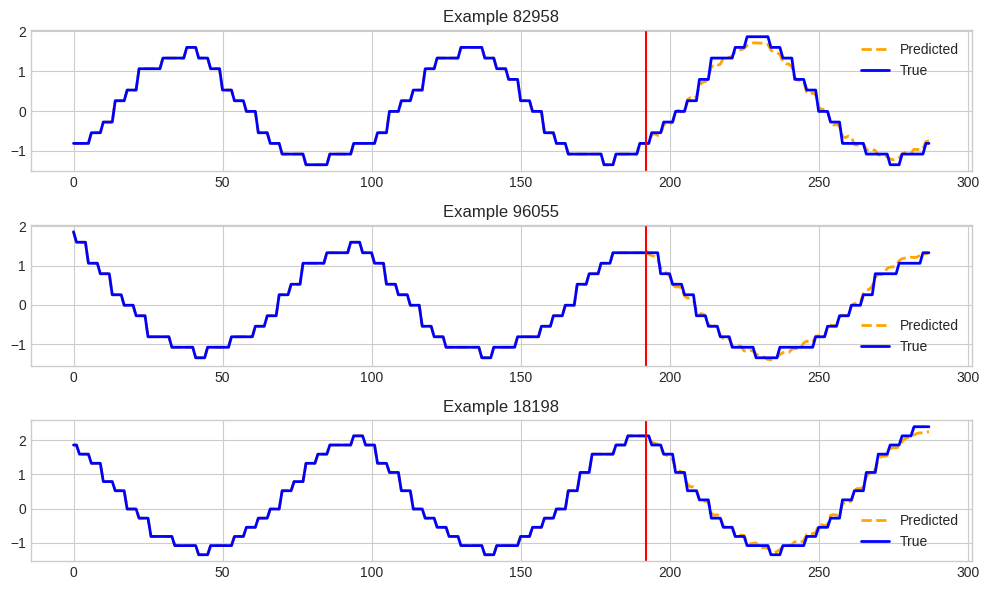

INFO:p-20818:t-139702636361472:base.py:run_job:Running job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 01:01:00 EEST)" (scheduled at 2024-10-14 01:00:45.137847+03:00)
INFO:p-20818:t-139702636361472:base.py:run_job:Job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 01:01:00 EEST)" executed successfully
INFO:p-20818:t-139702679353088:base.py:run_job:Running job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 01:01:04 EEST)" (scheduled at 2024-10-14 01:00:49.908461+03:00)
INFO:p-20818:t-139702679353088:base.py:run_job:Job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 01:01:04 EEST)" executed successfully
INFO:p-20818:t-139702636361472:base.py:run_job:Running job "EmissionsTracker._measure_power (trigger: interval[0:00:15], next run at: 2024-10-14 01:01:15 EEST)" (scheduled at 2024-10-14 01:01:00.137847+03:00)
INFO:p-20818:t-13970263

In [32]:
# plot
plot_predictions(
    model=finetune_forecast_trainer.model,
    dset=data_sets[0][2],
    plot_dir=os.path.join(OUT_DIR, "ettm2"),
    plot_prefix="test_zeroshot",
    channel=0,
    num_plots=3,
)